# Performance Analytics

This notebook computes Day 4 analytics for the 40 mutual fund schemes, including daily returns, CAGR, Sharpe, Sortino, alpha/beta, maximum drawdown, scorecards, and benchmark comparison visuals.

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import linregress

BASE_DIR = Path('..').resolve()
PROCESSED_DIR = BASE_DIR / 'data' / 'processed'
PLOTS_DIR = BASE_DIR / 'notebooks' / 'plots'
PLOTS_DIR.mkdir(parents=True, exist_ok=True)
RF_RATE = 0.065
TRADING_DAYS = 252

In [2]:
nav_history = pd.read_csv(PROCESSED_DIR / '02_nav_history.csv', parse_dates=['date'])
benchmark = pd.read_csv(PROCESSED_DIR / '10_benchmark_indices.csv', parse_dates=['date'])
fund_master = pd.read_csv(PROCESSED_DIR / '01_fund_master.csv')
scheme_perf = pd.read_csv(PROCESSED_DIR / '07_scheme_performance.csv')

nav_history = nav_history.sort_values(['amfi_code', 'date']).copy()
nav_history['daily_return'] = nav_history.groupby('amfi_code')['nav'].pct_change()
nav_history.head()

,date,amfi_code,nav,daily_return
0,2022-01-03,100016,520.4608,NaN
1,2022-01-04,100016,515.0971,-0.010306
2,2022-01-05,100016,521.7239,0.012865
3,2022-01-06,100016,515.7880,-0.011377
4,2022-01-07,100016,515.1639,-0.001210


## Daily Return Distribution Validation

In [3]:
daily_stats = nav_history['daily_return'].dropna().describe()
daily_stats

count    64280.000000
mean         0.000451
std          0.008706
min         -0.058102
25%         -0.002092
50%          0.000000
75%          0.003233
max          0.064713
Name: daily_return, dtype: float64

## Performance Metrics for All Funds

In [4]:
def compute_cagr(group, years):
    end_date = group['date'].max()
    target = end_date - pd.DateOffset(years=years)
    subset = group[group['date'] <= target].sort_values('date')
    if subset.empty:
        return np.nan
    start_nav = subset.iloc[-1]['nav']
    end_nav = group.loc[group['date'] == end_date, 'nav'].iloc[0]
    return (end_nav / start_nav) ** (1/years) - 1

benchmark_wide = benchmark.pivot(index='date', columns='index_name', values='close_value').sort_index()
benchmark_wide['NIFTY100_return'] = benchmark_wide['NIFTY100'].pct_change()

performance_rows = []
for code, group in nav_history.dropna(subset=['daily_return']).groupby('amfi_code', sort=False):
    group = group.sort_values('date').reset_index(drop=True)
    one_year = compute_cagr(group, 1)
    three_year = compute_cagr(group, 3)
    five_year = compute_cagr(group, 5)
    mean_daily = group['daily_return'].mean()
    vol_daily = group['daily_return'].std(ddof=0)
    ann_return = mean_daily * TRADING_DAYS
    ann_vol = vol_daily * np.sqrt(TRADING_DAYS)
    sharpe = (ann_return - RF_RATE) / ann_vol if ann_vol > 0 else np.nan
    downside = group.loc[group['daily_return'] < 0, 'daily_return']
    downside_std = downside.std(ddof=0)
    sortino = (ann_return - RF_RATE) / (downside_std * np.sqrt(TRADING_DAYS)) if downside_std > 0 else np.nan
    bench_df = benchmark_wide.reset_index()[['date', 'NIFTY100_return']]
    joined = pd.merge(group[['date', 'daily_return']], bench_df, on='date', how='inner')
    if not joined.empty:
        reg = linregress(joined['NIFTY100_return'], joined['daily_return'])
        beta = reg.slope
        alpha = reg.intercept * TRADING_DAYS
        tracking = np.nanstd((joined['daily_return'] - joined['NIFTY100_return']).values, ddof=0) * np.sqrt(TRADING_DAYS)
    else:
        beta = np.nan
        alpha = np.nan
        tracking = np.nan
    running_max = group['nav'].cummax()
    drawdowns = group['nav'] / running_max - 1
    trough_idx = drawdowns.idxmin()
    trough_date = group.loc[trough_idx, 'date']
    peak_date = group.loc[:trough_idx].loc[group.loc[:trough_idx, 'nav'] == running_max.loc[trough_idx], 'date'].max()
    performance_rows.append({
        'amfi_code': code,
        'scheme_name': fund_master.loc[fund_master['amfi_code'] == code, 'scheme_name'].iloc[0],
        '1yr_cagr_pct': one_year * 100 if pd.notna(one_year) else np.nan,
        '3yr_cagr_pct': three_year * 100 if pd.notna(three_year) else np.nan,
        '5yr_cagr_pct': five_year * 100 if pd.notna(five_year) else np.nan,
        'sharpe_ratio': sharpe,
        'sortino_ratio': sortino,
        'alpha_pct': alpha * 100 if pd.notna(alpha) else np.nan,
        'beta': beta,
        'tracking_error_pct': tracking * 100 if pd.notna(tracking) else np.nan,
        'max_drawdown_pct': drawdowns.min() * 100,
        'drawdown_start': peak_date,
        'drawdown_end': trough_date,
    })
performance_df = pd.DataFrame(performance_rows)
performance_df.head()

,amfi_code,scheme_name,1yr_cagr_pct,3yr_cagr_pct,5yr_cagr_pct,sharpe_ratio,sortino_ratio,alpha_pct,beta,tracking_error_pct,max_drawdown_pct,drawdown_start,drawdown_end
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,-2.224271,1.292649,NaN,-0.321119,-0.473231,3.747581,-0.058268,19.919686,-24.734441,2022-03-30,2022-09-15
1,100025,HDFC Short Term Debt Fund - Regular - Growth,3.704969,3.916390,NaN,-1.040265,-1.462553,4.281792,0.001158,13.447659,-4.308264,2023-05-23,2023-07-28
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,53.232396,32.442459,NaN,0.808519,1.145281,27.195355,0.005104,22.859988,-16.217209,2022-03-13,2022-05-12
3,101206,ABSL Frontline Equity Fund - Regular - Growth,47.924120,28.967695,NaN,0.717632,1.064897,21.399785,0.021086,19.262253,-11.291596,2023-04-24,2023-07-05
4,101207,ABSL Small Cap Fund - Regular - Growth,-23.986032,-4.152381,NaN,0.052635,0.075735,10.897092,-0.065289,29.199028,-35.446916,2024-11-21,2026-05-11


## Fund Scorecard

In [5]:
performance_df['rank_3yr'] = performance_df['3yr_cagr_pct'].rank(ascending=False, method='min')
performance_df['rank_sharpe'] = performance_df['sharpe_ratio'].rank(ascending=False, method='min')
performance_df = performance_df.merge(scheme_perf[['amfi_code', 'expense_ratio_pct']], on='amfi_code', how='left')
performance_df['rank_alpha'] = performance_df['alpha_pct'].rank(ascending=False, method='min')
performance_df['rank_expense'] = performance_df['expense_ratio_pct'].rank(ascending=True, method='min')
performance_df['rank_max_dd'] = performance_df['max_drawdown_pct'].rank(ascending=True, method='min')
for column in ['rank_3yr', 'rank_sharpe', 'rank_alpha', 'rank_expense', 'rank_max_dd']:
    performance_df[f'rank_pct_{column}'] = 100 * (1 - (performance_df[column] - 1) / (len(performance_df) - 1))
performance_df['fund_score'] = (
    performance_df['rank_pct_rank_3yr'] * 0.30 +
    performance_df['rank_pct_rank_sharpe'] * 0.25 +
    performance_df['rank_pct_rank_alpha'] * 0.20 +
    performance_df['rank_pct_rank_expense'] * 0.15 +
    performance_df['rank_pct_rank_max_dd'] * 0.10
)
scorecard = performance_df.sort_values('fund_score', ascending=False).reset_index(drop=True)
scorecard[['amfi_code', 'scheme_name', 'fund_score', '3yr_cagr_pct', 'sharpe_ratio', 'alpha_pct', 'expense_ratio_pct', 'max_drawdown_pct']].head()

,amfi_code,scheme_name,fund_score,3yr_cagr_pct,sharpe_ratio,alpha_pct,expense_ratio_pct,max_drawdown_pct
0,120505,ICICI Pru Midcap Fund - Regular - Growth,84.743590,31.777537,0.883531,29.263583,1.36,-18.188514
1,119094,Axis Midcap Fund - Regular - Growth,81.923077,35.111802,0.730774,26.076669,1.38,-20.960884
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,80.384615,32.442459,0.808519,27.195355,1.38,-16.217209
3,148567,Mirae Asset Large Cap Fund - Regular - Growth,79.487179,34.000916,1.068556,26.983751,1.46,-11.265729
4,120843,Kotak Flexicap Fund - Regular - Growth,77.692308,29.582770,0.965861,27.330465,1.45,-12.973968


## Benchmark Comparison Chart

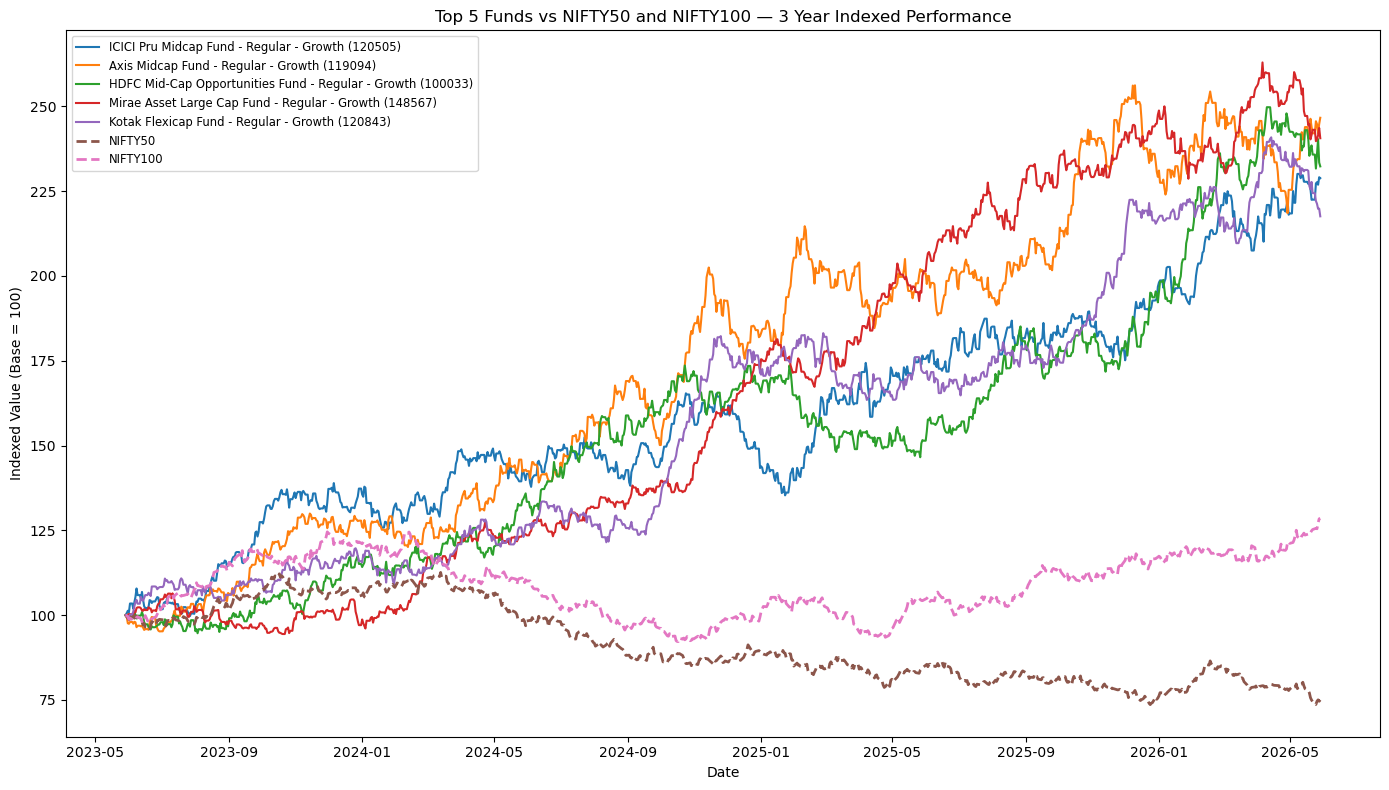

In [6]:
top5 = scorecard.head(5)['amfi_code'].tolist()
start_date = nav_history['date'].max() - pd.DateOffset(years=3)
plot_nav = nav_history[nav_history['amfi_code'].isin(top5) & (nav_history['date'] >= start_date)].copy()
plot_nav['indexed'] = plot_nav.groupby('amfi_code')['nav'].transform(lambda x: x / x.iloc[0] * 100)
bench_plot = benchmark[benchmark['index_name'].isin(['NIFTY50', 'NIFTY100']) & (benchmark['date'] >= start_date)].copy()
bench_plot['indexed'] = bench_plot.groupby('index_name')['close_value'].transform(lambda x: x / x.iloc[0] * 100)
plt.figure(figsize=(14, 8))
for code in top5:
    series = plot_nav[plot_nav['amfi_code'] == code]
    scheme_name = scorecard.loc[scorecard['amfi_code'] == code, 'scheme_name'].iloc[0]
    plt.plot(series['date'], series['indexed'], label=f"{scheme_name} ({code})")
for idx in ['NIFTY50', 'NIFTY100']:
    series = bench_plot[bench_plot['index_name'] == idx]
    plt.plot(series['date'], series['indexed'], linestyle='--', linewidth=2, label=idx)
plt.title('Top 5 Funds vs NIFTY50 and NIFTY100 — 3 Year Indexed Performance')
plt.xlabel('Date')
plt.ylabel('Indexed Value (Base = 100)')
plt.legend(loc='upper left', fontsize='small')
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'benchmark_comparison_chart.png')
plt.show()